## Airflow Concepts and Operations
* catch up and backfill
  + catch up:
    + if start date is Jan 02, 2025 and the unpause date (the date you trigger the pipeline) is Jan 05, 2025, the catch up will execute 3 dag runs corresponding to the intervals between 02-03, 03-04 and 04-05. Usually we set catchup = False to avoid large number of dag runs
    + if catchup = False, and start date is early than the unpause date, then there will be one dag run, which is the last missing dag.
    + if catchup = True, but a dag has been triggered after start date, then the last run the dag is triggered will be set as the start date.
      + if you want to catchup all the runs between start date and today, and you have triggered the dag after start date, you can
        + pause the dag, then from GUI, go to Browser-> dag runs, and delete the finished dags, then unpause the dag to run all catchup runs
  + backfill
    + if we set the start date as Jan 02, 2025, but found we actually need to run from Jan 01, 2025, we can manually back fill the dag runs between Jan 01 and Jan 02 from the command line by `airflow dags backfill -s <start> -e <end> dag_id`
    + To back fill a dag, you need to make sure your tasks are idempotent, meaning that they can be safely rerun multiple times without causing unintended consequences or duplicating data
    + if your tasks perform write operations or modify external systems, double-check that backfilling won't result in duplicate or inconsistent data
    + be careful when using Now() in sql query since it will generate duplicate results. Instead, using `{{date_interval_end}}` to represent the exact date end when doing backfill
    + using `INSERT OVERWRITE` or `UPSERT` to update / write results to database tables to avoid data duplicate or inconsistency
* Timezones
  + A timezone is a region of the globe that observes a uniform standard time
  + You can use either a cron expression or deltatime to schedule the dag
* a dataset can be a file, a table or a bucket
  + we can use datasets to define dependencies between DAGs
  + first, `from airflow import dataset`
  + define dataset `file = Dataset("/tmp/data.txt")` for both producer and consumer dags
  + in producer dag's file producing task, define `outlets=[file]` while in consumer dag, define `@dag(schedule=[file]`. This will trigger the consumer dag once the dataset is updated by producer. This provide the third trigger mechanism in addition to cron and deltatime
  + even if the producer task doesn't update the dataset, airflow will still trigger consumer dag if the producer task success. If the task does not success, airflow will not trigger the consumer dag
* conditional dataset scheduling
  + use & (AND), | (OR) to set up conditions with multiple datasets to trigger dags
  + `@dag(schedule=[a,b])` will wait for both a and b datasets are updated. You have to use \[]\ for unconditional dataset scheduling
  + `@dag(schedule=(a | b))` will wait for either a or b datasets are updated. You have to use \()\ since this is conditional dataset scheduling
  + `@dag(schedule=((a | b) & (c | d)))`
* astro folders and imports
  + astro automatically add include folder in the python path. files in this folder will be imported as part of include package
  + you can add tasks.py, datasets.py etc to include folder. When importing these python file, ignore the relative path relationship, just use `from include.datasets import DATASET_COCKTAIL`, even from include.tasks.py, you still use `include.datasets` since include is a python package to import, and this package has been added to the python path by astro

* callback functions:
  + call back functions can have context as input
  + you can define the failure/sucess call back functions in @dag declaration using `on_success_callback` and `on_failure_callback`, respectively
  + you can define failure/success/skip/execution/retry at task level and set these in task declaurations
* default_args:
  + define default_args in @dag declaration that apply to dag level as follows:
  ``` python
    @dag(
    start_date=datetime(2025, 1, 1),
    schedule='@daily',
    catchup=False,
    on_failure_callback=_handle_failed_dag_run,
    default_args={
        'retries': 2,
        'retry_delay': duration(seconds=2),
        'retry_exponential_backoff': True,
        'max_retry_delay': duration(hours=   1
   )``
  + you can define these arguments at task level
* tests
  + `astro dev parse`: parses DAGs, ensure there are no import errors
  + `astro dev pytest`: runs all tests in the tests/ folder
  + `astro dev upgrade-test`: Tests the environment against new Airflow/Runtime versions
  + `airflow dags test`: executes a single DAG run
  + `airflow tasks test`: executes a single task
 
  + dag test allows you to debug without using scheduler and in IDE with breakpoints and debug tools
    ```python
    if __name__ == "__main__":
        conn_path = "connections.ymal"
        var_path = "variables.yaml"

        my_dag.test(
            execution_date=datetime(2025, 1, 1)
            conn_file_path=conn_path,
            variable_file_path=var_path
            )
    ```
    + dag validation tests to ensure all imports and configs such as default args of retries are correct using @pytest.mark.parameterize
    + unit tests check hooks and operators, including the python call back functions for operators works
    + integration tests: workflow of your dag works as expected.
  + astro has built-in pytest docker to run pytest by running `astro dev pytest --verbosity debug`
    + by default, this will run pytests in tests\dags\test_dag_example.py
  + dag tests
    + first, create a dag instance
    + second set up python script as main and run dag.test as follows:
      ```python
      # create a dag instance
      my_extractor = extractor()
      if __name__ == "__main__":
          my_extract
     ```     or.test()
    + make sure you install apache-airflow in the running environment
    + include the current path in PYTHONPATH by `export PYTHONPATH=/path_to_current_project`
    + run `airflow db migrate` to migrate the meta database from postgres docker to sqlite
    + run the current script as main in vs code, and then click 'run and debug' button. You can set break points before you click and run the debug 
* task group
  + you can group tasks into a task group. it is easy to organize tasks.
  + use @task_group inside a dag, and define the corresponding function whose name will be task group's id.
  + inside the task group, define the individual tasks, and organize the tasks in the task group
  + outside of the task group, define the denpendencies of other tasks with the task group. remember to call the task group function since it is a decorator
  + you can nest task groups
  + to access a task inside a task group, use task group id as the prefix of the task id
  ```python
  @dag(    
    start_date=datetime(2025, 1, 1),    
    schedule='@daily'    ,
    catchup=Fals    e,
    on_failure_callback=_handle_failed_dag_r    un,
    tags=["eco    m"],
    default_a    rgs={
        'retrie    s': 2,
        'retry_delay': duration(seco    nds=2),
        'retry_exponential_backoff    ': True,
        'max_retry_delay': duration    (hours    =1    )
    }
)
def     e    xtractor():

    get_cocktail = P    ythonOperator(
        task_id=    'get_cocktail',
        python_callabl    e=_get_cocktail,
        outlets=[D    ATASET_COCKTAIL],
        retry_exponen    tial_backoff=True,
        max_retry_delay=d    uratio    n    (minutes=15)
        )

    @task_group(
                default_args={
                    "re    tries"     : 3
                }
    )
    def check():
            check_size = PythonOperator(
                task_id='check_size',
                python_callable=_check_size,
            on_fail    ure_callba    c    k=_handle_empty_size
        )

            validate_fields = PythonOperator(
                    task_id='validate_fields',
                pytho    n_callable=_va    lidate_cocktail_fields
            )    
            check_size >> validate_f  ields

  
```
ktail >> check()   

extractor()       in
    }
)`

* branch operators
  + use task.branch() decorator as branch python operator
  + in the function, apply conditions and return the task id, or task group id for different conditions. remember to use task group prefix if the task id is in a task group.
  + there are other branch operators, such as branch sql operator (whether a sql returns true or false), branch based on weekdays etc.
* trigger rules
  + decide whether or not to run a task depending on the execution of other tasks
  + defualt rule: run a task if all its upstream tasks are successful (trigger rule: ALL_SUCCESS)
  + you can set trigger rule as ALL_FAILED to run a task and skip the task if any of the upstream tasks are successful
  + ALL_DONE doesn't care the states of upstream tasks. It execute the task after all its upstream tasks are executed.
  + ALL_SKIPPED: run task if all upstream tasks are skipped
  + ONE_FAILED: run tasks if one upstream tasks is failed
  + ONE_SUCCESS: run tasks if one upstream tasks is successful
  + ONE_DONE: run tasks if one upstream tasks is done
  + NONE_FAILED: run tasks if none of the upstream tasks are failed. They are either successful or skipped. Otherwise, the task is in upstream failed state
  + NONE_FAILED_MIN_ONE_SUCCESS
    + all upstream tasks are finished
    + no upstream tasks are in failed or upstream failed state
    + at least one upstream task is in success state
    + otherwise, task is in upstream failed state
    + if all upstream tasks are in skipped state, then task will be skipped
    + This is useful when a branch task is the upstream task where one of the upstream will be skipped.
  + NONE_SKIPPED
    + upstream tasks can be in success, upstream failed or failed, but not skipped state to execute the task
    + Otherwise, the task will be skipped
  + ALWAYS
    + always runs the task as soon as the dag runs even if the upstream tasks are not scheduled
  + to implement, use `airflow.utils.trigger_rule.TriggerRule` class
* Template
  + Airflow has a set of internally defined variables that can be access from operators using template `{{}}`.
  + This allows you to define value at run time.
  + templates are defined within strings in templateable parameters with two pairs of curly brackets {{}}
  + Airflow provides variables such as ds, ti, logical_date etc.
  + not all parameters of an operator are templateable. Look at template_fields in the Operator's code to know which one is
  + to use template, e.g. `{{ ds }}` in @task, you need to pass the value as a dictionary entry to @task parameter, and then reference the value from dictionary key
    ```python
    @task(template_dict={'the_current_date': '{{ ds }}'})
    def clean_data(template_dict):
        import os
        if os.path.exists(DATASET_COCKTAIL.uri):
            os.remove(DATASET_COCKTAIL.uri)
        else:
            print('file does not exist')
        print(f'data cleaned for the date {template_dict['the_current_date'] }')
     ```   
* xcom backend
  + you can set up to use s3 as the xcom backend instead of using the prostgres db with a size threshold
  + the process is the following
    + set up a s3 bucket, and create a user for airflow with the read and wirte access to the s3 bucket granted for that user by creating a user policy
    + create access id and sceret access id for airflow user
    + in Airflow connections, set up an AWS service with the access and secret access ids
    + in Airflow requirements.txt file, add the following packages:
      + apache-airflow-providers-common-io
      + apache-airflow-providers-amazon\[s3fs\]
    + in .env file, set up the following envirnoment variables:
      + AIRFLOW__CORE__XCOM_BACKEND="airflow.providers.common.io.xcom.backend.XComObjectStorageBackend"
      + AIRFLOW__COMMON_IO__XCOM_OBJECTSTORAGE_PATH="s3://your_aws_connection@your_s3_bucket_name/xcom"
      + AIRFLOW__COMMON_IO__XCOM_OBJECTSTORAGE_THRESHOLD="-1" # -1 means all to s3, other positive number means the size threshold in bytes      
* Airflow variables
  + stored in Airflow meta database
  + can create from Airflow GUI from Admin-> variable
  + can create variables from Airflow cli `astro dev run variables set my_number 84`
  + in .env file `AIRFLOW_VAR_MY_NUMBER=128`. You need to restart your Airflow and you can not see this variable from variable GUI or cli
  + in functions such as a @task function (not recommended)
    ```python
    def _get_cocktail(ti=None):
        import requests
        from airflow.models import Variable

        Variable.set('my_number', 200)

    ```
    + to use the variable, in your function code, use it inside a function. Don't retrieve the variables at module level in a dag file. Otherwise, each time Airflow parse the dag file, it will request the variables from database, even if you don't run the tasks for variable retrieval.
      ```python
      def _get_variable():
          from airflow.models import Variable
          api = Variable.get('my_number')
      ```
      + you can also access the variables from templates
      ```python
      @task(templates_dict={
          'my_api': '{{ var.value.api }}'
          })
      def _get_variable(templates_dict):
          api = templates_dict['my_api']
      ```    
* Airflow Scheduler ane Executor
  + executor is part of scheduler to execute the tasks (where and how the tasks are executed)
  + schedulor is responsible for scheduling tasks
  + when using SQLite as the database, you can only use SequentialExecutor since SQLite only accept single connections at a time
    + you set `AIRFLOW__DATABASE__SQL_ALCHEMY_CONN=sqlite:///{AIRFLOW_HOME}/airflow.db` as the path of sqlite db and `AIRFLOW__CORE__EXECUTOR=SequentialExecutor`
  + Local Executor runs tasks within scheduler process, but can run as many taks at the same time as you can on your local machine (don't have to be sequentially as in SequentialExecutor)
    + can not use Sqlite, most cases using PostgresSQL database
    + the default settings of astro using PostgresSQL database and local executor, which you can find from the env inside scheduler docker
* concurrency settings
  + parallelism = 32: max number of task instances allowd to run concurrently in each scheduler in each single environment across dgas. This restricts the total number of task instances in both queued and running states for a scheduler across all dags
  + max_active_tasks_per_dag = 16: max number of tasks that can be scheduled at the same time across all runs for a dag (dag level definition as max_active_tasks=2)
  + max_active_runs_per_dag = 1: run dags sequentially (dag level definition as max_active_runs=1)
  + max_active_tis_per_dag = 1 at task level @task(max_active_tis_per_dag=1): if you have mutilple dag runs for this dag, then you can only have one of this task instance scheduled across all dag runs.
* CeleryExecutor
  + a distributed task queue to distribute tasks to multiple machines
  + tasks are scheduled in a Redis queue and workers pull tasks from Redis queue
  + task A is scheduled by scheduler to the queue with the status of "queued"
  + worker 1 pull task A from the queue and task A is now in status of "running"
  + worker 1 then update the state of task A in the meta database
  + each worker can execute multiple tasks, with the default value of worker_concurrency = 16
  + to use CeleryExecutor, we don't use astro cli, which works with LocalExecutor
  + to add a worker to airflow CeleryExecutor, run `celery worker` on the machine to join the machine to Airflow

* Airflow on Kubernetes
  + set up Kind on docker desktop
    + upgrade wsl by downloading the .msi file for x64 from https://github.com/microsoft/WSL/releases/
    + unintall docker desktop if you have an old version of docke desktop, and then install the new version
    + your docker desktop will be managed by wsl for automatically resource management
    + go to docker desktop, then settings -> kubernetes -> enable kubernetes -> select kind with 2 nodes, version 1.32.3
    + after docke desktop shows that kubernetes running, then go to powershell and test if kubectl works
  + install airflow on kubernetes cluster
    + install helm on Windows by powershell (remember to open powershell as admin) using `choco install kubernetes-helm`
    + `helm repo add apache-airflow https://airflow.apache.org` to add airflow repo
    + find the appropriate helm chart version of airflow 2.10.5 by `helm search repo apache-airflow/airflow --versions`. The chart version is 1.16.0
    + create a namespace for airflow app, for example, `kubectl create namespace airflow`
    + install airflow app in airflow namespace by `helm install airflow apache-airflow/airflow --namespace airflow2 --version 1.16.0`
    + check all pods and svcs are installed by `kubectl get pods -n airflow2` and `kubectl get svc -n airflow2`
    + follow the installation instruction to forward webserver port to a local machine by `kubectl port-forward svc/airflow-webserver 8080:8080 --namespace airflow2`
    + open localhost:8080 for webserver GUI, and use "admin", "admin" for username and password to login
  + manage airflow from k8s
    + mkdir a new directory, go to the directory and execute `helm show values apache-airflow/airflow > values.yaml` in power shell to output airflow yaml file
    + in the directory, type `. code` to open vscode
    + open the value.yaml file, and change the line 71 and 77 to specify defaultAirflowTag and airflowVersion to 2.10.5 for both
    + in line 375, set executor to `executor: "KubernetesExecutor"`, and save the file
    + in terminal, type `helm ls -n airflow2` to list the app installed in this namespace, and check if app version is 2.10.5
    + upgrade the version to 2.10.5 and executor by `helm upgrade airflow apache-airflow/airflow -n airflow2 -f values.yaml --debug`
    + after the upgrade, do port forward by `kubectl port-forward svc/airflow-webserver 8080:8080 --namespace airflow2`
    + check if you can access webserver page by localhost:8080
  + set up gitsync
    + in values.yaml file, section dags-> gitSync, enabled=true (line 2948)
    + set repo, branch, ref and subPath (if dags file in the root folder, set it as ""). see screenshot below:
    + 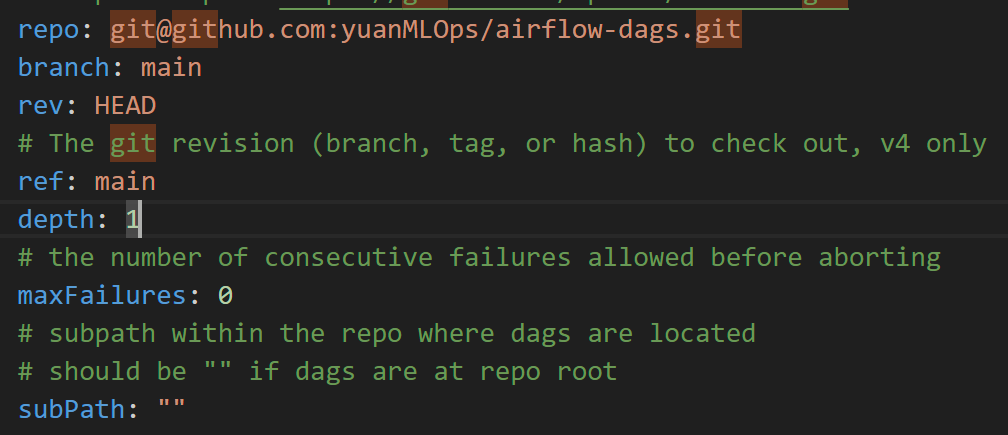
    + uncomment line 2994, `sshKeySecret: airflow-ssh-secret`
    + create the secret of sshKeySecret by `kubectl create secret generic airflow-ssh-secret --from-file=gitSshKey=C:/Users/huang/.ssh/id_ed25519 -n airflow2`
    + upgrade k8s by `helm upgrade airflow apache-airflow/airflow -n airflow2 -f values.yaml`
    + run `kubectl port-forward svc/airflow-webserver 8080:8080 --namespace airflow2`
    + now you can trigger dags from webserver page!

* mount windows shared folder on ubuntu server
  + install cifs
    `sudo apt update`
    `sudo apt install cifs-utils`
  + create a mounting point
    `sudo mkdir -p /mnt/K`
  + create a credential file
    `vi /etc/smb-credentials`
    in the file, type in
    ```shell
    username=your_windows_username
    password=your_windws_password
    ```
  + secure the file
    `sudo chmod 600 /etc/smb-credentials`
  + test by `sudo mount -t cifs //TU-SRV-FILE-01/BATTERY /mnt/K -o credentials=/etc/smb-credentials`
  + get your user id and group id by `id -u` and `id -g`. usually the values are 1000 for both
  + if works then add the following line to /etc/fstab
    `//TU-SRV-FILE-01/BATTERY /mnt/K cifs credentials=/etc/smb-credentials,file_mode=0777,dir_mode=0777,uid=1000,gid=1000 0 0`
  + run `sudo systemctl daemon-reload` and `sudo mount -a`  

### install helm and airflow on ubuntu and access airflow from windows
* install helm and airflow
  + install longhorn to set up persistent volumnes by `kubectl apply -f https://raw.githubusercontent.com/longhorn/longhorn/v1.9.0/deploy/longhorn.yaml`
  + you can access the UI by `kubectl port-forward -n longhorn-system svc/longhorn-frontend 8080:80`
  + longhorn service listens to port 80, and port forward it to master node's 8080 port
  + from your windows, you use ssh tunneling to forward your 8080 port to master node ip:8080

* access airflow running on k8s from windows
  + from powershell run `ssh -L 8080:localhost:8080 airflow_sh@10.10.10.35. it will then ask you password to ssh to 10.10.10.35
  + from the master node you install airflow, run `kubectl port-forward svc/airflow-webserver 8080:8080 --namespace airflow`
  + open browser on your windows pc, and type localhost:8080, you will see the airflow page
  + close the browser and on ubuntu master node, break the port forward by ctrl c. 